✅ Imports complete

=== DATASET INFORMATION ===
Shape: (20, 11)
Date range: 2026-09-01 00:00:00 to 2026-09-07 00:00:00

=== FIRST 5 ROWS ===
  order_date order_time platform  customer_phone        item_name  quantity  \
0 2026-09-01      19:30   Swiggy      9876543210   Paneer Biryani         2   
1 2026-09-01      20:00   Zomato      9876543211      Veg Biryani         1   
2 2026-09-01      20:15   Swiggy      9876543212     Paneer Tikka         2   
3 2026-09-02      19:00   Direct      9876543213      Masala Dosa         3   
4 2026-09-02      19:30   Zomato      9876543214  Chicken Biryani         1   

   unit_price  commission_pct  prep_time  delivery_time     status  
0         180              25         15             35  delivered  
1         160              28         15             40  delivered  
2         220              25         20             35  delivered  
3         120               0         12             25  delivered  
4         250              28         2

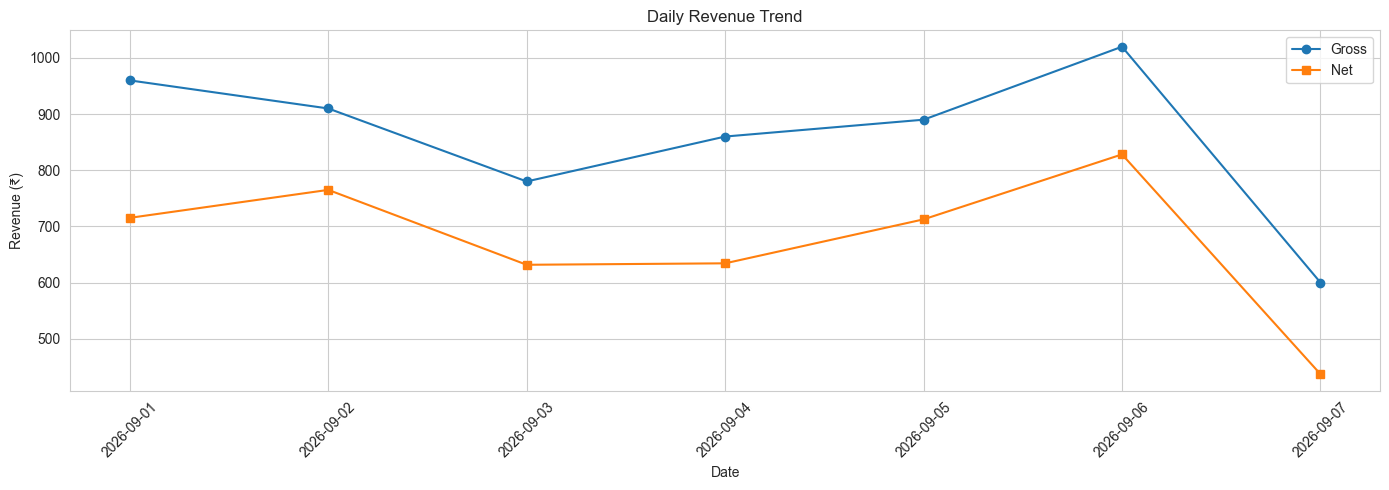


6. MENU PERFORMANCE

=== ITEM PERFORMANCE ===
                 quantity  gross_revenue  net_revenue
item_name                                            
Paneer Tikka            5           1100        866.8
Butter Chicken          3            840        604.8
Masala Dosa             5            600        600.0
Chicken Biryani         3            750        540.0
Veg Biryani             3            480        435.2
Paneer Biryani          3            540        405.0
Veg Fried Rice          3            480        360.0
Dal Makhani             3            450        337.5
Chole Bhature           3            420        315.0
Manchurian              2            360        259.2


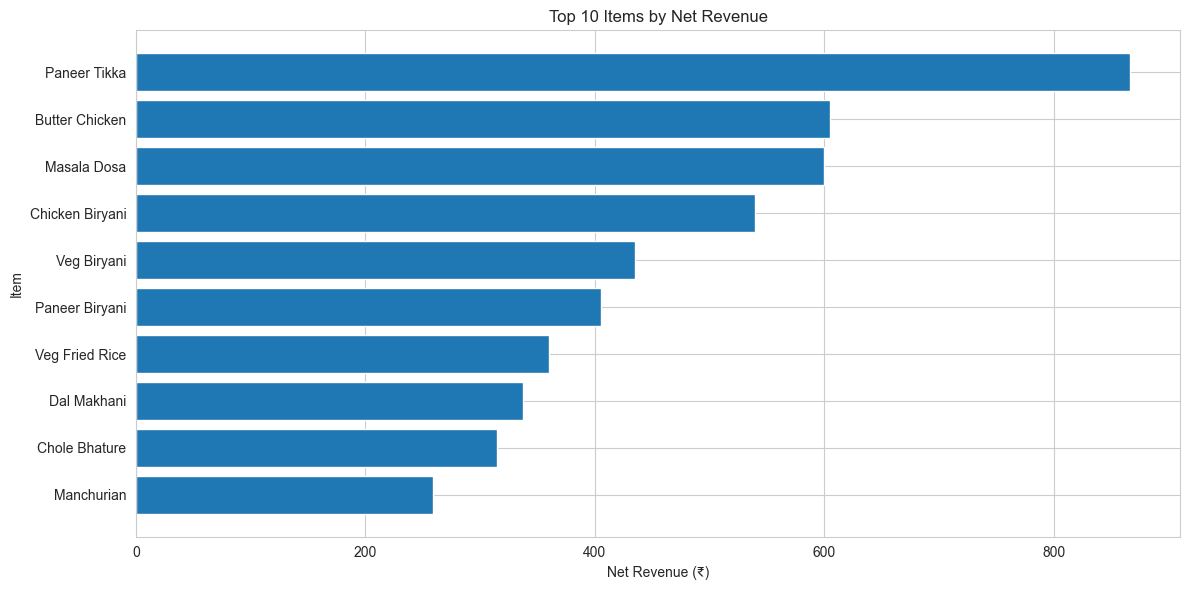


7. CUSTOMER ANALYSIS

Total customers: 20
Repeat customers: 0
Repeat rate: 0.0%
Average customer value: ₹301

=== TOP 5 CUSTOMERS ===
                total_spent first_order last_order  order_count
customer_phone                                                 
9876543226              560  2026-09-06 2026-09-06            1
9876543223              500  2026-09-05 2026-09-05            1
9876543212              440  2026-09-01 2026-09-01            1
9876543229              440  2026-09-07 2026-09-07            1
9876543210              360  2026-09-01 2026-09-01            1

8. DELIVERY PERFORMANCE

=== DELIVERY METRICS ===
Average prep time: 16.6 min
Average delivery time: 34.2 min
Total average time: 50.9 min
Late orders (>45 min): 0 (0.0%)

=== DELIVERY BY PLATFORM ===
          delivery_time  prep_time
platform                          
Direct             27.5       14.8
Swiggy             32.8       14.9
Zomato             40.0       20.0


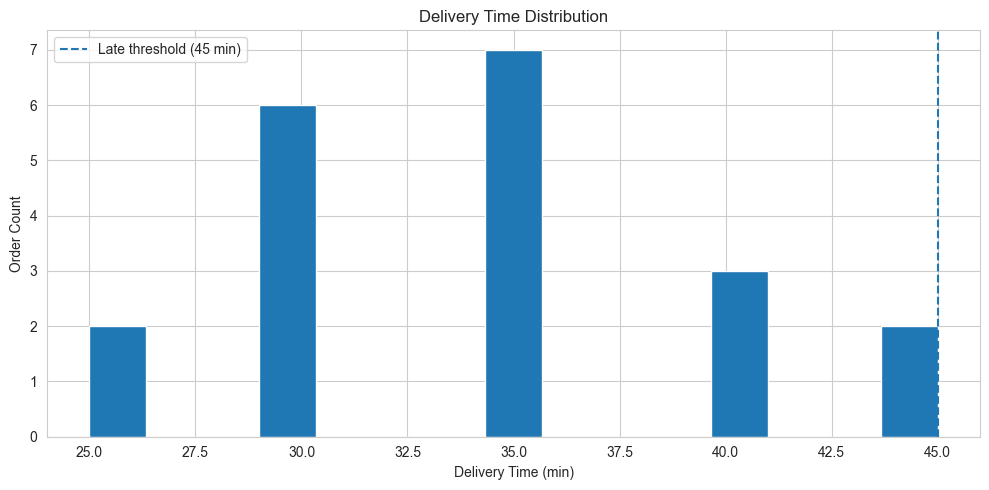


9. KEY INSIGHTS

1. Commission impact: 21.5% of gross revenue
2. Platform with highest net revenue: Zomato
   Net revenue: ₹1,836
3. Top item: Paneer Tikka
   Net revenue: ₹867
4. Repeat customer rate: 0.0%
5. Late delivery rate: 0.0%

✅ EDA ANALYSIS COMPLETE


In [1]:
# ============================================================
# 🍱 Cloud Kitchen Analytics — EDA
# Exploratory Data Analysis for Cloud Kitchen Operations
# ============================================================

# ============================================================
# 1. Setup & Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Imports complete")


# ============================================================
# 2. Load Data
# ============================================================

# Update this path if your CSV is located somewhere else
file_path = "../../frontend/assets/sample-data/sample-orders.csv"

df = pd.read_csv(file_path)

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

print("\n=== DATASET INFORMATION ===")
print(f"Shape: {df.shape}")
print(f"Date range: {df['order_date'].min()} to {df['order_date'].max()}")

print("\n=== FIRST 5 ROWS ===")
print(df.head())


# ============================================================
# 3. Data Quality Checks
# ============================================================

print("\n" + "=" * 60)
print("3. DATA QUALITY")
print("=" * 60)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Data types
print("\nData types:")
print(df.dtypes)


# ============================================================
# 4. Descriptive Statistics
# ============================================================

print("\n" + "=" * 60)
print("4. DESCRIPTIVE STATISTICS")
print("=" * 60)

# Add computed columns
df["gross_revenue"] = df["quantity"] * df["unit_price"]

df["net_revenue"] = (
    df["gross_revenue"]
    * (1 - df["commission_pct"] / 100)
)

df["commission_paid"] = (
    df["gross_revenue"] - df["net_revenue"]
)

print("\n=== KEY METRICS ===")

print(f"Total orders: {len(df):,}")

print(
    f"Total gross revenue: "
    f"₹{df['gross_revenue'].sum():,.0f}"
)

print(
    f"Total net revenue: "
    f"₹{df['net_revenue'].sum():,.0f}"
)

print(
    f"Total commission: "
    f"₹{df['commission_paid'].sum():,.0f}"
)

print(
    f"Average order value: "
    f"₹{df['gross_revenue'].mean():,.0f}"
)

print("\n=== NUMERICAL SUMMARY ===")
print(df.describe())


# ============================================================
# 5. Revenue Analysis
# ============================================================

print("\n" + "=" * 60)
print("5. REVENUE ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# Revenue by Platform
# ------------------------------------------------------------

platform_rev = (
    df.groupby("platform")
    .agg({
        "gross_revenue": "sum",
        "net_revenue": "sum",
        "commission_paid": "sum",
        "commission_pct": "mean"
    })
    .round(2)
)

print("\n=== REVENUE BY PLATFORM ===")
print(platform_rev)


# ------------------------------------------------------------
# Daily Revenue Trend
# ------------------------------------------------------------

daily = (
    df.groupby("order_date")
    .agg({
        "gross_revenue": "sum",
        "net_revenue": "sum",
        "quantity": "sum"
    })
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily["order_date"],
    daily["gross_revenue"],
    marker="o",
    label="Gross"
)

plt.plot(
    daily["order_date"],
    daily["net_revenue"],
    marker="s",
    label="Net"
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 6. Menu Performance
# ============================================================

print("\n" + "=" * 60)
print("6. MENU PERFORMANCE")
print("=" * 60)


# ------------------------------------------------------------
# Item Performance
# ------------------------------------------------------------

item_perf = (
    df.groupby("item_name")
    .agg({
        "quantity": "sum",
        "gross_revenue": "sum",
        "net_revenue": "sum"
    })
    .round(2)
    .sort_values(
        "net_revenue",
        ascending=False
    )
)

print("\n=== ITEM PERFORMANCE ===")
print(item_perf)


# ------------------------------------------------------------
# Top 10 Items
# ------------------------------------------------------------

top10 = item_perf.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10.index,
    top10["net_revenue"]
)

plt.xlabel("Net Revenue (₹)")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Revenue")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ============================================================
# 7. Customer Analysis
# ============================================================

print("\n" + "=" * 60)
print("7. CUSTOMER ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# Customer Statistics
# ------------------------------------------------------------

customer_stats = (
    df.groupby("customer_phone")
    .agg({
        "gross_revenue": "sum",
        "order_date": ["min", "max", "count"]
    })
)

customer_stats.columns = [
    "total_spent",
    "first_order",
    "last_order",
    "order_count"
]

print(
    f"\nTotal customers: "
    f"{len(customer_stats):,}"
)

repeat_customers = (
    customer_stats["order_count"] >= 2
).sum()

print(
    f"Repeat customers: "
    f"{repeat_customers:,}"
)

repeat_rate = (
    customer_stats["order_count"].ge(2).mean()
    * 100
)

print(
    f"Repeat rate: "
    f"{repeat_rate:.1f}%"
)

print(
    f"Average customer value: "
    f"₹{customer_stats['total_spent'].mean():,.0f}"
)


# ------------------------------------------------------------
# Top 5 Customers
# ------------------------------------------------------------

print("\n=== TOP 5 CUSTOMERS ===")

print(
    customer_stats
    .nlargest(5, "total_spent")
)


# ============================================================
# 8. Delivery Performance
# ============================================================

print("\n" + "=" * 60)
print("8. DELIVERY PERFORMANCE")
print("=" * 60)


# ------------------------------------------------------------
# Overall Delivery Metrics
# ------------------------------------------------------------

avg_prep_time = df["prep_time"].mean()
avg_delivery_time = df["delivery_time"].mean()

print("\n=== DELIVERY METRICS ===")

print(
    f"Average prep time: "
    f"{avg_prep_time:.1f} min"
)

print(
    f"Average delivery time: "
    f"{avg_delivery_time:.1f} min"
)

print(
    f"Total average time: "
    f"{avg_prep_time + avg_delivery_time:.1f} min"
)


# ------------------------------------------------------------
# Late Orders
# ------------------------------------------------------------

late = (
    df["delivery_time"] > 45
).sum()

late_percentage = (
    late / len(df) * 100
)

print(
    f"Late orders (>45 min): "
    f"{late:,} "
    f"({late_percentage:.1f}%)"
)


# ------------------------------------------------------------
# Delivery by Platform
# ------------------------------------------------------------

delivery_by_platform = (
    df.groupby("platform")
    .agg({
        "delivery_time": "mean",
        "prep_time": "mean"
    })
    .round(1)
)

print("\n=== DELIVERY BY PLATFORM ===")
print(delivery_by_platform)


# ------------------------------------------------------------
# Delivery Time Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    df["delivery_time"],
    bins=15,
    edgecolor="white"
)

plt.axvline(
    45,
    linestyle="--",
    label="Late threshold (45 min)"
)

plt.xlabel("Delivery Time (min)")
plt.ylabel("Order Count")
plt.title("Delivery Time Distribution")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 9. Key Insights
# ============================================================

print("\n" + "=" * 60)
print("9. KEY INSIGHTS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Commission Impact
# ------------------------------------------------------------

commission_percentage = (
    df["commission_paid"].sum()
    / df["gross_revenue"].sum()
    * 100
)

print(
    f"\n1. Commission impact: "
    f"{commission_percentage:.1f}% "
    f"of gross revenue"
)


# ------------------------------------------------------------
# 2. Platform with Highest Net Revenue
# ------------------------------------------------------------

best_platform = (
    platform_rev["net_revenue"]
    .idxmax()
)

best_platform_revenue = (
    platform_rev.loc[
        best_platform,
        "net_revenue"
    ]
)

print(
    f"2. Platform with highest net revenue: "
    f"{best_platform}"
)

print(
    f"   Net revenue: "
    f"₹{best_platform_revenue:,.0f}"
)


# ------------------------------------------------------------
# 3. Top Performing Menu Item
# ------------------------------------------------------------

best_item = (
    item_perf["net_revenue"]
    .idxmax()
)

best_item_revenue = (
    item_perf.loc[
        best_item,
        "net_revenue"
    ]
)

print(
    f"3. Top item: "
    f"{best_item}"
)

print(
    f"   Net revenue: "
    f"₹{best_item_revenue:,.0f}"
)


# ------------------------------------------------------------
# 4. Repeat Customer Rate
# ------------------------------------------------------------

print(
    f"4. Repeat customer rate: "
    f"{repeat_rate:.1f}%"
)


# ------------------------------------------------------------
# 5. Late Delivery Rate
# ------------------------------------------------------------

print(
    f"5. Late delivery rate: "
    f"{late_percentage:.1f}%"
)


# ============================================================
# END
# ============================================================

print("\n" + "=" * 60)
print("✅ EDA ANALYSIS COMPLETE")
print("=" * 60)